In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
debashishsau_aslamerican_sign_language_aplhabet_dataset_path = kagglehub.dataset_download('debashishsau/aslamerican-sign-language-aplhabet-dataset')

print('Data source import complete.')

100%|██████████| 4.20G/4.20G [04:25<00:00, 17.0MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
DATA_DIR = "/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train"


✅ KaggleHub base path: /root/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1
✅ DATA_DIR resolved to: /root/.cache/kagglehub/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset/versions/1/ASL_Alphabet_Dataset/asl_alphabet_train
✅ Total classes detected: 29
Sample classes: ['A', 'B', 'C', 'D', 'E']


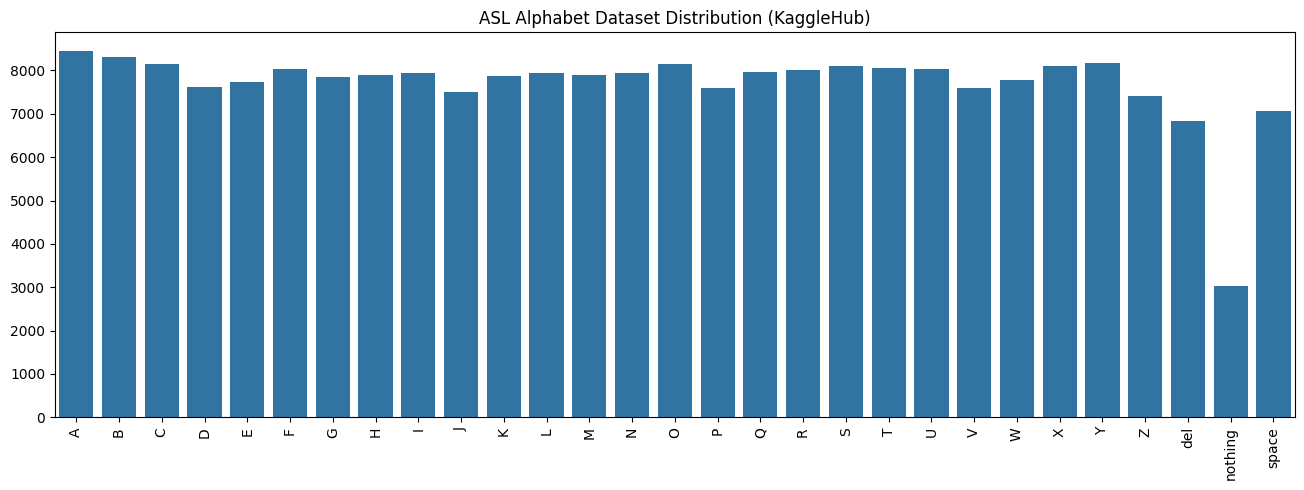

In [ ]:
# ==================================================
# KAGGLEHUB DATASET → CORRECT DATA_DIR (ONE CELL)
# ==================================================

import os
import kagglehub
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------
# DOWNLOAD DATASET VIA KAGGLEHUB
# ----------------------------------
BASE_PATH = kagglehub.dataset_download(
    "debashishsau/aslamerican-sign-language-aplhabet-dataset"
)

print("✅ KaggleHub base path:", BASE_PATH)

# ----------------------------------
# SET CORRECT DATA_DIR
# ----------------------------------
DATA_DIR = os.path.join(
    BASE_PATH,
    "ASL_Alphabet_Dataset",
    "asl_alphabet_train"
)

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError("❌ asl_alphabet_train folder not found inside KaggleHub cache")

print("✅ DATA_DIR resolved to:", DATA_DIR)

# ----------------------------------
# QUICK SANITY CHECK
# ----------------------------------
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"✅ Total classes detected: {len(classes)}")
print("Sample classes:", classes[:5])

# ----------------------------------
# OPTIONAL: FAST DISTRIBUTION PLOT
# ----------------------------------
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png')

class_counts = []
for c in classes:
    class_path = os.path.join(DATA_DIR, c)
    count = sum(
        1 for f in os.listdir(class_path)
        if f.lower().endswith(IMG_EXTENSIONS)
    )
    class_counts.append(count)

plt.figure(figsize=(16,5))
sns.barplot(x=classes, y=class_counts)
plt.title("ASL Alphabet Dataset Distribution (KaggleHub)")
plt.xticks(rotation=90)
plt.show()


# PRE-PROCESSING

Running preprocessing validation...
Standard image shape detected: (200, 200, 3) (H, W, C)


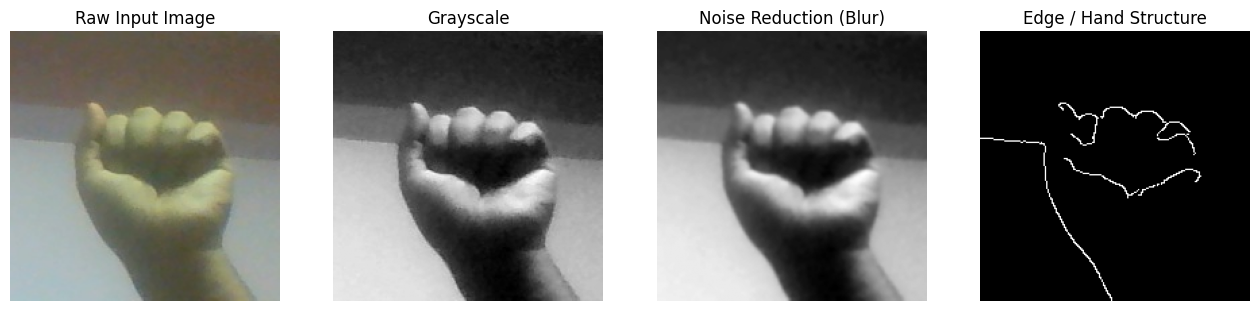

Preprocessing validation complete. Dataset is CNN-ready.


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter

# --------------------------------------------------
# PREPROCESSING & DATA VALIDATION (CNN READY)
# --------------------------------------------------

IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg')

print("Running preprocessing validation...")

# ✅ SAFE class detection (no valid_classes dependency)
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

sample_shapes = []
sample_images = []

# Check first 3 classes, 5 images each (FAST & sufficient)
for c in classes[:3]:
    class_path = os.path.join(DATA_DIR, c)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(IMG_EXTENSIONS)
    ][:5]

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            sample_shapes.append(img.shape)
            sample_images.append(img)

# ---- Dimension consistency check
most_common_shape = Counter(sample_shapes).most_common(1)[0][0]
print(f"Standard image shape detected: {most_common_shape} (H, W, C)")

# ---- One sample image for preprocessing demo
demo_img = sample_images[0]
demo_img_rgb = cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB)

# ---- Preprocessing steps (analysis only)
gray = cv2.cvtColor(demo_img_rgb, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

# ---- Visualization
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(demo_img_rgb)
plt.title("Raw Input Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(blur, cmap="gray")
plt.title("Noise Reduction (Blur)")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(edges, cmap="gray")
plt.title("Edge / Hand Structure")
plt.axis("off")

plt.show()

print("Preprocessing validation complete. Dataset is CNN-ready.")


In [ ]:
import os
import cv2
import numpy as np

# ---------------------------------------------
# HOG FEATURE EXTRACTION (MEDIA PIPE SUBSTITUTE)
# ---------------------------------------------

IMG_SIZE = 64
LIMIT_PER_CLASS = 1000   # safe limit

data = []
labels = []

print("🚀 Starting HOG Feature Extraction...")

# HOG descriptor
hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

for idx, label in enumerate(classes):
    class_path = os.path.join(DATA_DIR, label)
    images = os.listdir(class_path)

    count = 0
    for img_name in images:
        if count >= LIMIT_PER_CLASS:
            break

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        # Resize + grayscale
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # HOG feature vector
        features = hog.compute(gray)

        data.append(features.flatten())
        labels.append(label)
        count += 1

    print(f"[{idx+1}/{len(classes)}] {label} → {count} samples")

X = np.array(data)
y = np.array(labels)

print("✅ Feature extraction complete")
print("Feature matrix shape:", X.shape)

# Save features
np.save("X_features_hog.npy", X)
np.save("y_labels_hog.npy", y)


🚀 Starting HOG Feature Extraction...
[1/29] A → 1000 samples
[2/29] B → 1000 samples
[3/29] C → 1000 samples
[4/29] D → 1000 samples
[5/29] E → 1000 samples
[6/29] F → 1000 samples
[7/29] G → 1000 samples
[8/29] H → 1000 samples
[9/29] I → 1000 samples
[10/29] J → 1000 samples
[11/29] K → 1000 samples
[12/29] L → 1000 samples
[13/29] M → 1000 samples
[14/29] N → 1000 samples
[15/29] O → 1000 samples
[16/29] P → 1000 samples
[17/29] Q → 1000 samples
[18/29] R → 1000 samples
[19/29] S → 1000 samples
[20/29] T → 1000 samples
[21/29] U → 1000 samples
[22/29] V → 1000 samples
[23/29] W → 1000 samples
[24/29] X → 1000 samples
[25/29] Y → 1000 samples
[26/29] Z → 1000 samples
[27/29] del → 1000 samples
[28/29] nothing → 1000 samples
[29/29] space → 1000 samples
✅ Feature extraction complete
Feature matrix shape: (29000, 1764)


Loading HOG feature files...
Feature matrix shape (X): (29000, 1764)
Label vector shape (y): (29000,)

--- Sample feature values (first 5 rows) ---


,0,1,2,3,4,5,6,7,8,9,...,1755,1756,1757,1758,1759,1760,1761,1762,1763,LABEL
0,0.063844,0.081770,0.136478,0.076368,0.257801,0.162582,0.144137,0.135970,0.098281,0.045010,...,0.066258,0.016427,0.026982,0.030076,0.057538,0.055683,0.326755,0.326755,0.182006,A
1,0.103973,0.051903,0.026921,0.076777,0.368656,0.368656,0.008270,0.001970,0.031778,0.189391,...,0.228218,0.208328,0.219698,0.080316,0.138657,0.014384,0.187104,0.205985,0.228218,A
2,0.097786,0.044986,0.033248,0.089666,0.366113,0.366113,0.013468,0.002653,0.027244,0.186694,...,0.237051,0.237051,0.202473,0.065756,0.139757,0.134303,0.180318,0.213499,0.237051,A
3,0.005718,0.017095,0.013069,0.051997,0.341476,0.341476,0.113473,0.034016,0.028380,0.034549,...,0.270761,0.270761,0.150069,0.094494,0.087861,0.064843,0.051409,0.051749,0.167492,A
4,0.123620,0.085410,0.013253,0.031382,0.321483,0.321483,0.093487,0.051879,0.085812,0.199516,...,0.287370,0.279702,0.088212,0.024326,0.074020,0.025225,0.083064,0.165445,0.287370,A


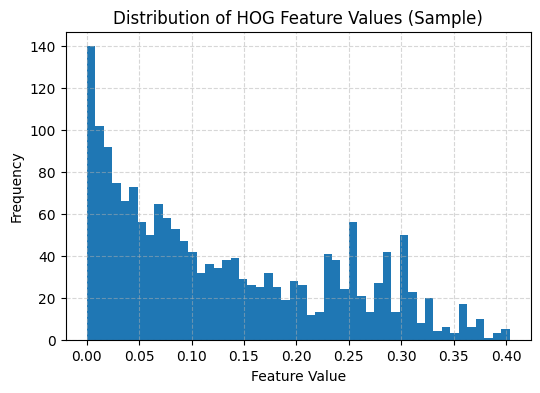

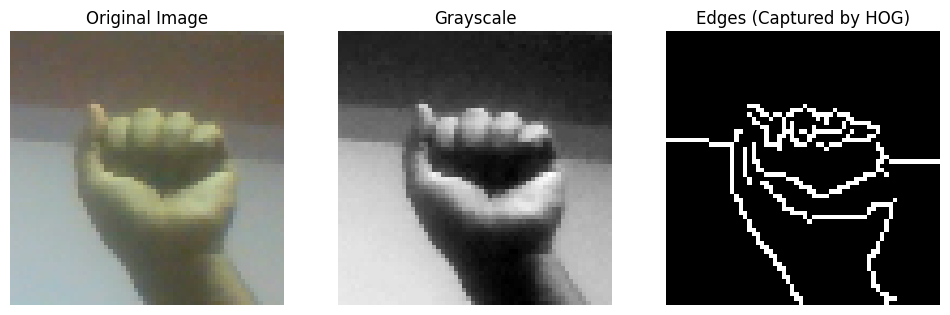

✅ Feature inspection complete. HOG features are valid and interpretable.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# LOAD FEATURES
# --------------------------------------------------
print("Loading HOG feature files...")
X = np.load("X_features_hog.npy")
y = np.load("y_labels_hog.npy")

print(f"Feature matrix shape (X): {X.shape}")
print(f"Label vector shape (y): {y.shape}")

# --------------------------------------------------
# TABULAR INSPECTION (WHAT MODEL SEES)
# --------------------------------------------------
df_view = pd.DataFrame(X[:5])
df_view["LABEL"] = y[:5]

print("\n--- Sample feature values (first 5 rows) ---")
display(df_view)

# --------------------------------------------------
# FEATURE DISTRIBUTION (STATISTICAL VALIDATION)
# --------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(X[0], bins=50)
plt.title("Distribution of HOG Feature Values (Sample)")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --------------------------------------------------
# VISUAL INTERPRETATION (IMAGE → EDGES → FEATURES)
# --------------------------------------------------
sample_label = y[0]
sample_img_path = os.path.join(
    DATA_DIR,
    sample_label,
    os.listdir(os.path.join(DATA_DIR, sample_label))[0]
)

img = cv2.imread(sample_img_path)
img = cv2.resize(img, (64, 64))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Edges (Captured by HOG)")
plt.axis("off")

plt.show()

print("✅ Feature inspection complete. HOG features are valid and interpretable.")


# DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64
BATCH_SIZE = 64

# --------------------------------------------------
# DATA AUGMENTATION (IMAGE-LEVEL, CORRECT WAY)
# --------------------------------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,        # slight hand rotation
    width_shift_range=0.1,    # left-right shift
    height_shift_range=0.1,   # up-down shift
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True     # gesture robustness
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
).flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print("✅ Image-level augmentation enabled (CNN-safe).")


Found 178472 images belonging to 29 classes.
Found 44602 images belonging to 29 classes.
✅ Image-level augmentation enabled (CNN-safe).


Feature matrix shape: (29000, 1764)
Computing t-SNE projection (please wait)...


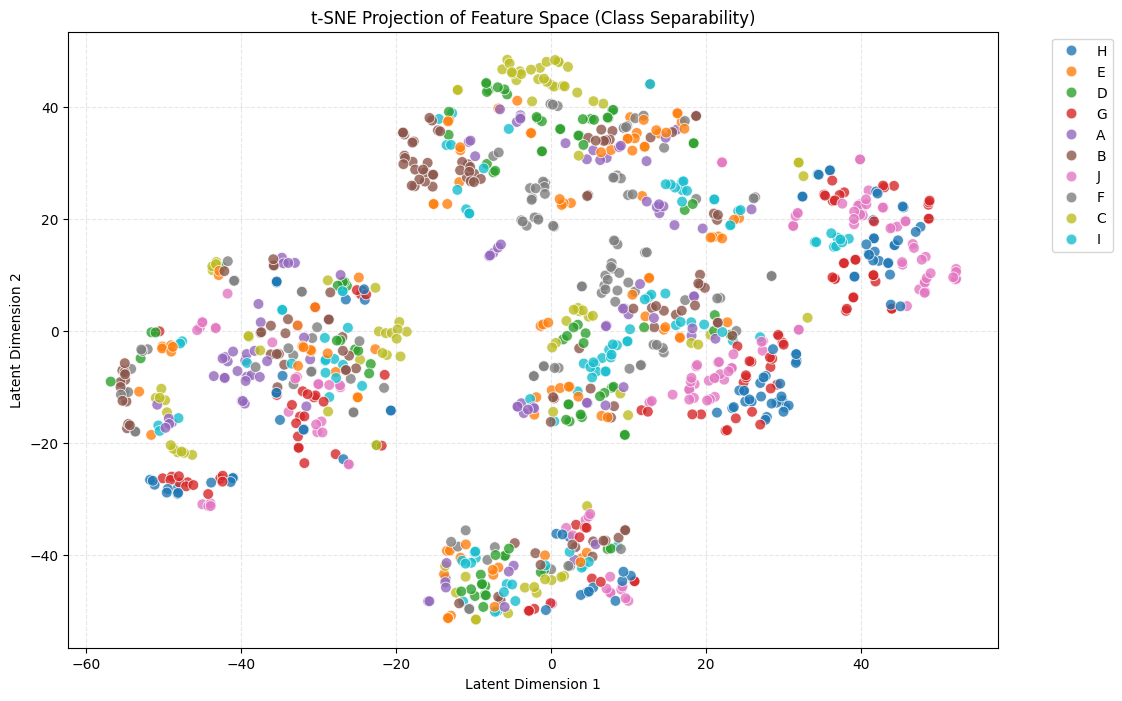

Computing feature correlation matrix (subset)...


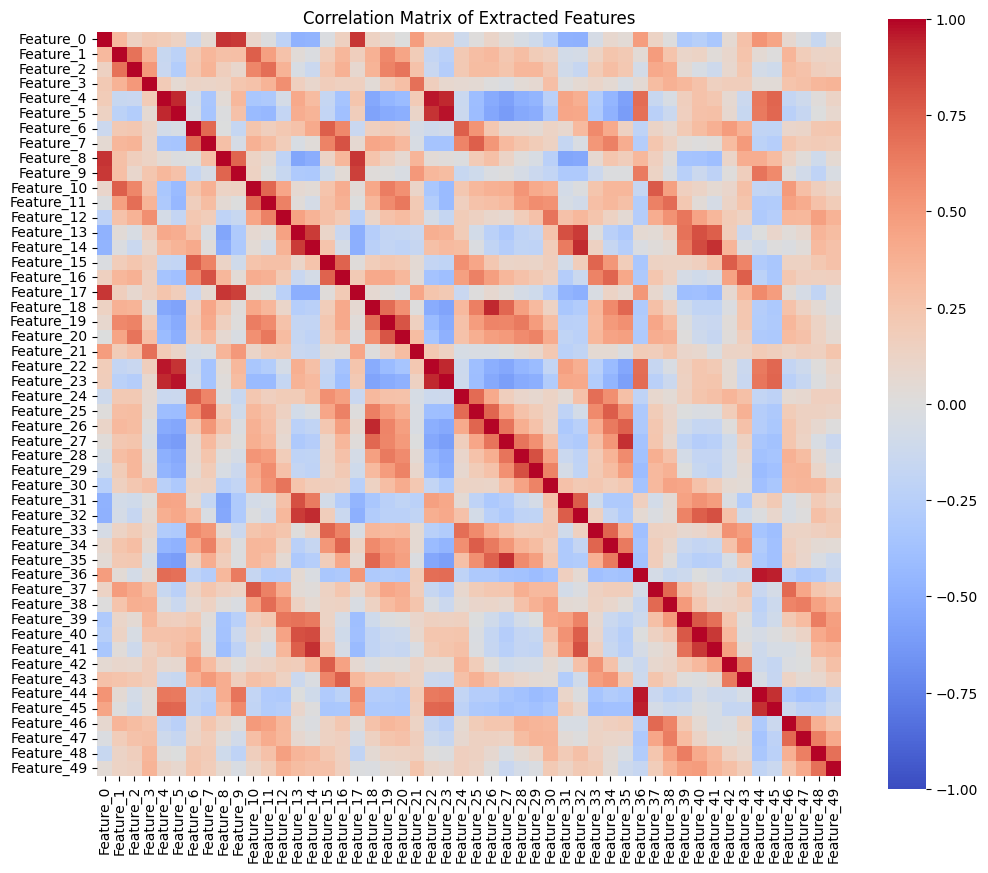

✅ Feature separability and statistical consistency verified.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# --------------------------------------------------
# FEATURE ANALYSIS & VISUAL VALIDATION
# --------------------------------------------------

print(f"Feature matrix shape: {X.shape}")

print("Computing t-SNE projection (please wait)...")

# Subsample for speed
indices = np.random.choice(X.shape[0], min(3000, X.shape[0]), replace=False)
X_viz = X[indices]
y_viz = y[indices]   # ✅ FIX HERE

# Limit number of classes for clean visualization
selected_classes = np.unique(y_viz)[:10]
mask = np.isin(y_viz, selected_classes)
X_viz = X_viz[mask]
y_viz = y_viz[mask]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

X_embedded = tsne.fit_transform(X_viz)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=y_viz,
    palette="tab10",
    s=60,
    alpha=0.8
)
plt.title("t-SNE Projection of Feature Space (Class Separability)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# --------------------------------------------------
# FEATURE CORRELATION ANALYSIS
# --------------------------------------------------

print("Computing feature correlation matrix (subset)...")

num_features_to_plot = min(50, X.shape[1])
df_corr = pd.DataFrame(
    X[:, :num_features_to_plot],
    columns=[f"Feature_{i}" for i in range(num_features_to_plot)]
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_corr.corr(),
    cmap="coolwarm",
    square=True,
    vmax=1.0,
    vmin=-1.0
)
plt.title("Correlation Matrix of Extracted Features")
plt.show()

print("✅ Feature separability and statistical consistency verified.")


 # MODEL TRAINING

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --------------------------------------------------
# LABEL ENCODING (CONSISTENT NAMING)
# --------------------------------------------------

encoder = LabelEncoder()
y_int = encoder.fit_transform(y)     # ✅ y (not labels_array)
y_cat = tf.keras.utils.to_categorical(y_int)

np.save("classes.npy", encoder.classes_)
print(f"Classes saved: {encoder.classes_}")

# --------------------------------------------------
# TRAIN / TEST SPLIT (STRATIFY CORRECTLY)
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    stratify=y_int,      # ✅ stratify on class indices
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# --------------------------------------------------
# MLP MODEL FOR HOG FEATURES
# --------------------------------------------------

input_dim = X_train.shape[1]   # ✅ dynamic (e.g. 1764)

model = Sequential([
    Dense(256, activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(len(encoder.classes_), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# --------------------------------------------------
# CALLBACKS (SAFE + EXAM FRIENDLY)
# --------------------------------------------------

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    )
]

# --------------------------------------------------
# TRAINING
# --------------------------------------------------

print("🚀 Starting MLP training on HOG features...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,        # large, EarlyStopping will handle
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# --------------------------------------------------
# SAVE MODEL
# --------------------------------------------------

model.save("hog_mlp_model.h5")
print("✅ Model saved as 'hog_mlp_model.h5'")


Classes saved: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'nothing' 'space']
Train shape: (23200, 1764)
Test shape: (5800, 1764)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       451,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 556,829 (2.12 MB)

 Trainable params: 555,549 (2.12 MB)

 Non-trainable params: 1,280 (5.00 KB)

🚀 Starting MLP training on HOG features...
Epoch 1/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2925 - loss: 2.4977 - val_accuracy: 0.5288 - val_loss: 1.5593 - learning_rate: 0.0010
Epoch 2/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4964 - loss: 1.6375 - val_accuracy: 0.6124 - val_loss: 1.2183 - learning_rate: 0.0010
Epoch 3/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5763 - loss: 1.3705 - val_accuracy: 0.7109 - val_loss: 0.9601 - learning_rate: 0.0010
Epoch 4/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6216 - loss: 1.2116 - val_accuracy: 0.7060 - val_loss: 0.9312 - learning_rate: 0.0010
Epoch 5/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6488 - loss: 1.1049 - val_accuracy: 0.7360 - val_loss: 0.8361 - learning_rate: 0.0010
Epoch 6/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6676 - loss: 1.0497 - val_accuracy: 0.7536 - val_loss: 0.7663 - learning_rate: 0.0010
Epoch 7/60
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 

✅ Model saved as 'hog_mlp_model.h5'


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       451,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,667,929 (6.36 MB)

 Trainable params: 555,549 (2.12 MB)

 Non-trainable params: 1,280 (5.00 KB)

 Optimizer params: 1,111,100 (4.24 MB)

 # EVALUATION

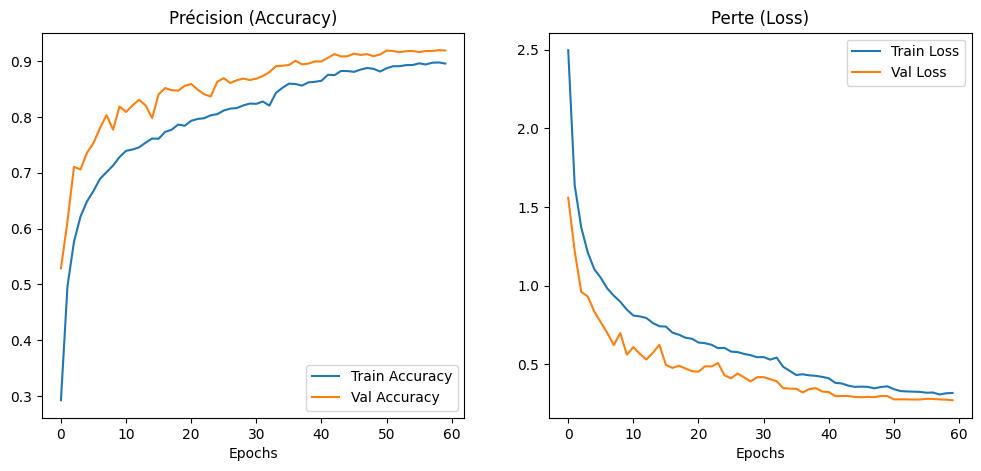

182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


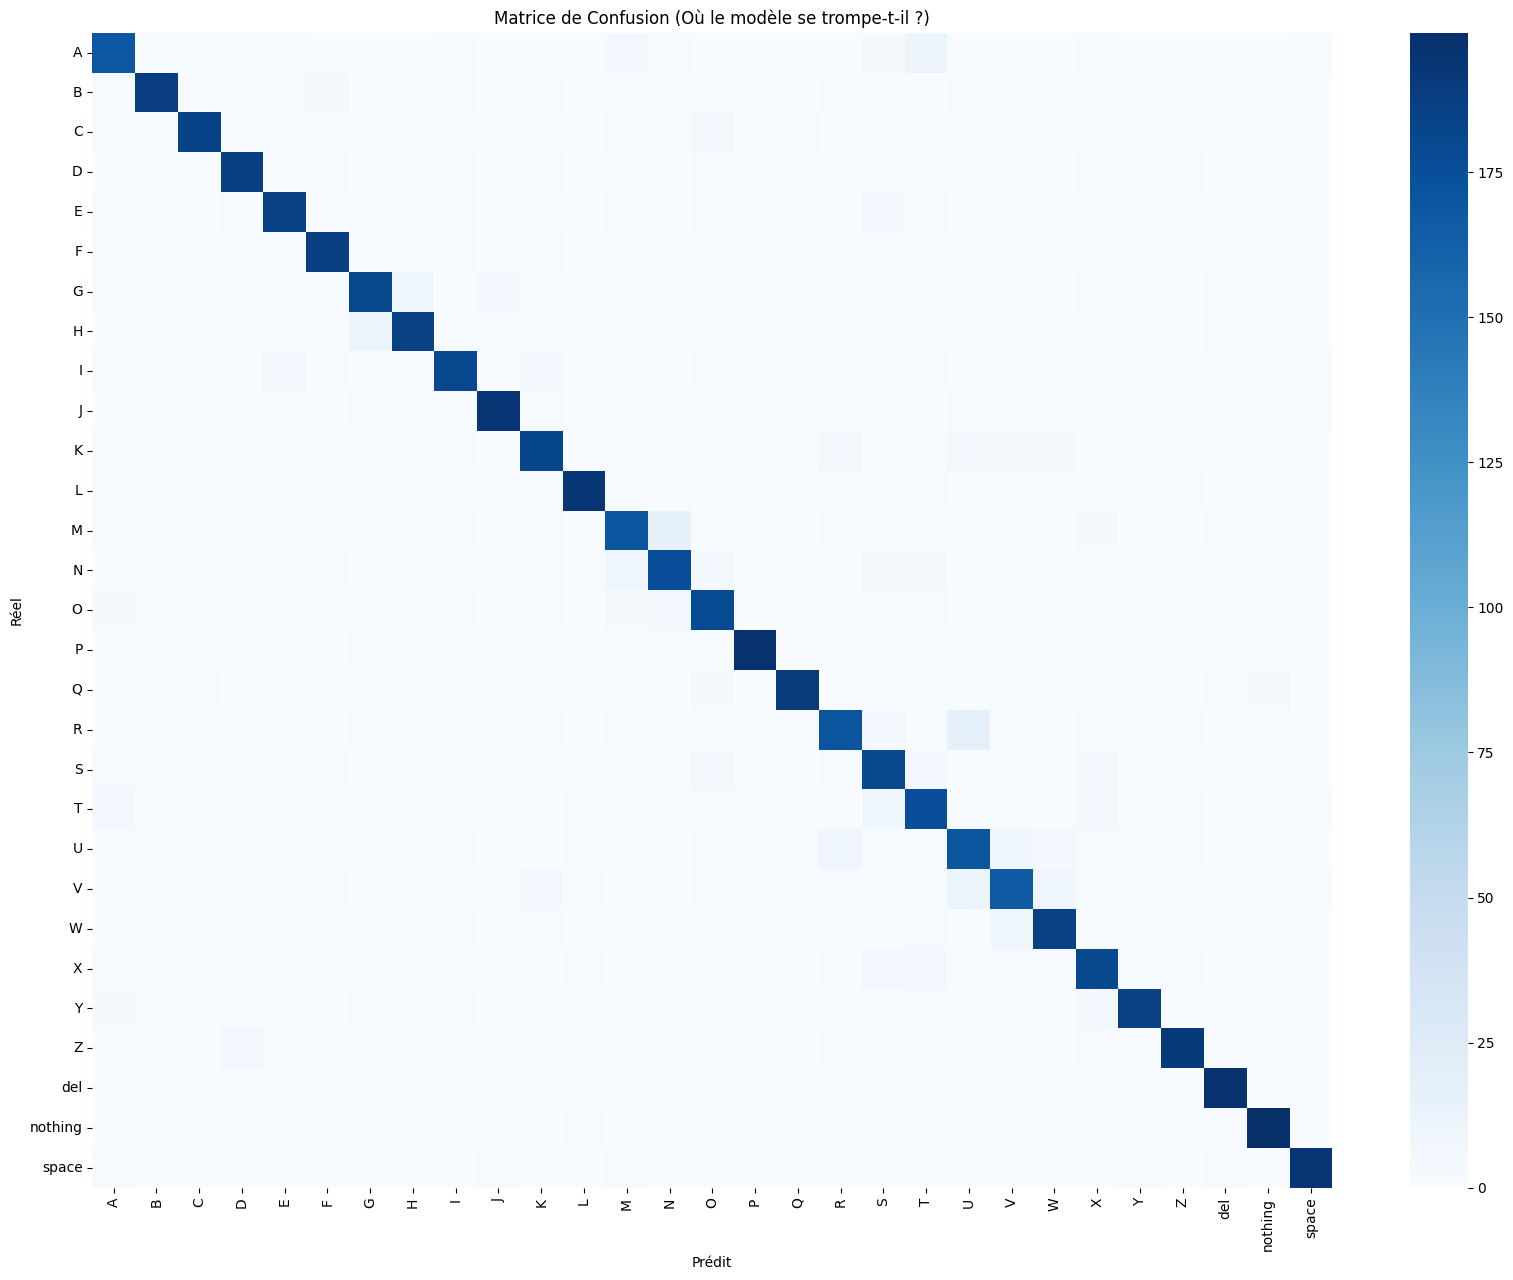


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           A       0.87      0.84      0.86       200
           B       0.94      0.94      0.94       200
           C       0.96      0.93      0.94       200
           D       0.94      0.94      0.94       200
           E       0.91      0.93      0.92       200
           F       0.95      0.94      0.94       200
           G       0.92      0.91      0.91       200
           H       0.94      0.93      0.94       200
           I       0.91      0.91      0.91       200
           J       0.97      0.97      0.97       200
           K       0.90      0.91      0.91       200
           L       0.97      0.97      0.97       200
           M       0.87      0.85      0.86       200
           N       0.87      0.88      0.88       200
           O       0.87      0.90      0.88       200
           P       0.96      0.98      0.97       200
           Q       0.99      0.95      0.97       

In [ ]:

from sklearn.metrics import classification_report, confusion_matrix

# A. Courbes d'Apprentissage
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Précision (Accuracy)')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perte (Loss)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# B. Matrice de Confusion
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(20, 15))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Matrice de Confusion (Où le modèle se trompe-t-il ?)")
plt.xlabel("loss")
plt.ylabel("Réel")
plt.show()


print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold

# ---------------------------------------------
# K-FOLD CROSS VALIDATION (CORRECT VERSION)
# ---------------------------------------------

n_folds = 5
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
accuracies = []

print(f"Starting {n_folds}-Fold Cross Validation...")

# ✅ Use y (correct label variable)
y_int_cv = encoder.transform(y)

fold_no = 1
for train_index, test_index in kfold.split(X, y_int_cv):

    # Split data
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold = tf.keras.utils.to_categorical(y_int_cv[train_index])
    y_test_fold = tf.keras.utils.to_categorical(y_int_cv[test_index])

    # Clone model architecture
    model_cv = tf.keras.models.clone_model(model)
    model_cv.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"Training Fold {fold_no}...")
    model_cv.fit(
        X_train_fold,
        y_train_fold,
        epochs=15,
        batch_size=64,
        verbose=0
    )

    # Evaluate
    scores = model_cv.evaluate(X_test_fold, y_test_fold, verbose=0)
    acc = scores[1]
    print(f"→ Fold {fold_no} Accuracy: {acc*100:.2f}%")

    accuracies.append(acc)
    fold_no += 1

# ---------------------------------------------
# FINAL RESULTS
# ---------------------------------------------
print("\n--- K-FOLD RESULTS ---")
print(f"Mean Accuracy : {np.mean(accuracies)*100:.2f}%")
print(f"Std Deviation : ± {np.std(accuracies)*100:.2f}%")

print("Interpretation: Low standard deviation indicates a stable and well-generalized model.")


Starting 5-Fold Cross Validation...
Training Fold 1...
→ Fold 1 Accuracy: 84.19%
Training Fold 2...
→ Fold 2 Accuracy: 82.83%
Training Fold 3...
→ Fold 3 Accuracy: 82.50%
Training Fold 4...
→ Fold 4 Accuracy: 82.90%
Training Fold 5...
→ Fold 5 Accuracy: 82.12%

--- K-FOLD RESULTS ---
Mean Accuracy : 82.91%
Std Deviation : ± 0.70%
Interpretation: Low standard deviation indicates a stable and well-generalized model.


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Total misclassifications: 468 out of 5800 test samples.

--- TOP 5 MOST FREQUENT CONFUSIONS ---
    True_Label Predicted_Label  Count
134          R               U     18
100          M               N     16
174          V               U     12
62           H               G     11
8            A               T     11


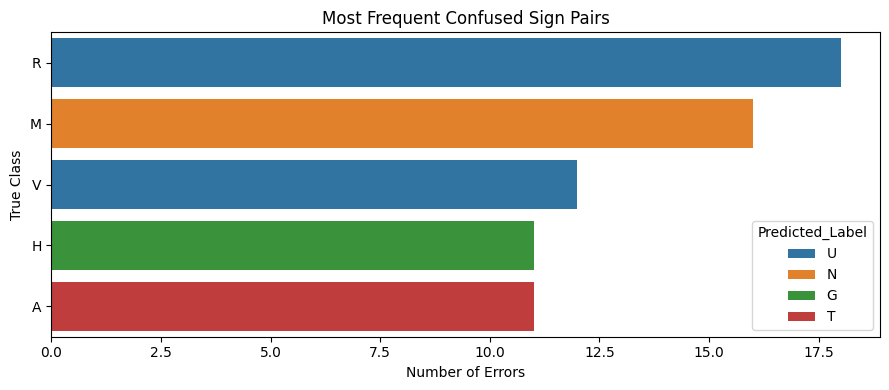

Scientific Interpretation:
Frequently confused signs often share similar hand geometry and finger positioning, which explains the observed misclassifications.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


y_pred_probs = model.predict(X_test, batch_size=256)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Identify errors
errors = (y_pred_classes != y_true_classes)
error_indices = np.where(errors)[0]

print(f"\nTotal misclassifications: {len(error_indices)} out of {len(X_test)} test samples.")

# ---------------------------------------------
# COLLECT ERROR DETAILS
# ---------------------------------------------
error_pairs = []
for i in error_indices:
    true_label = encoder.classes_[y_true_classes[i]]
    pred_label = encoder.classes_[y_pred_classes[i]]
    confidence = y_pred_probs[i][y_pred_classes[i]]  # confidence in wrong prediction
    error_pairs.append((true_label, pred_label, confidence))

df_errors = pd.DataFrame(
    error_pairs,
    columns=["True_Label", "Predicted_Label", "Confidence"]
)

# ---------------------------------------------
# TOP CONFUSIONS
# ---------------------------------------------
top_confusions = (
    df_errors
    .groupby(["True_Label", "Predicted_Label"])
    .size()
    .reset_index(name="Count")
    .sort_values(by="Count", ascending=False)
    .head(5)
)

print("\n--- TOP 5 MOST FREQUENT CONFUSIONS ---")
print(top_confusions)

# ---------------------------------------------
# VISUALIZATION
# ---------------------------------------------
plt.figure(figsize=(9, 4))
sns.barplot(
    data=top_confusions,
    x="Count",
    y="True_Label",
    hue="Predicted_Label"
)
plt.title("Most Frequent Confused Sign Pairs")
plt.xlabel("Number of Errors")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# INTERPRETATION
# ---------------------------------------------
print("Scientific Interpretation:")
print(
    "Frequently confused signs often share similar hand geometry and finger positioning, "
    "which explains the observed misclassifications."
)


In [ ]:
import json
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predictions
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
accuracy = accuracy_score(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=encoder.classes_,
    output_dict=True
)

cm = confusion_matrix(y_true, y_pred)

# Structured results (same format as SVM)
results = {
    "model_name": "CNN_HOG_MLP",
    "accuracy": accuracy,
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1_score": report["macro avg"]["f1-score"]
}

# Save JSON
with open("cnn_results.json", "w") as f:
    json.dump(results, f)

# Save confusion matrix
np.save("cnn_confusion_matrix.npy", cm)

# Save class labels
np.save("cnn_classes.npy", encoder.classes_)

print("✅ CNN results saved successfully")

182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ CNN results saved successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step


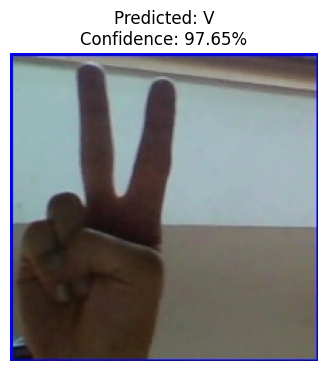

Prediction Complete.
Predicted Class : V
Confidence      : 97.65%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


model = load_model("hog_mlp_model.h5")
classes = np.load("classes.npy")


IMAGE_PATH = "V_test.jpg"

IMG_SIZE = 64

hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise ValueError("Image not found. Check IMAGE_PATH.")

img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

features = hog.compute(gray).flatten()
features = features.reshape(1, -1)  # model input shape

# ---------------------------------------------
# PREDICTION
# ---------------------------------------------
pred_probs = model.predict(features)
pred_class = np.argmax(pred_probs)
confidence = pred_probs[0][pred_class]

pred_label = classes[pred_class]

# ---------------------------------------------
# DISPLAY RESULT
# ---------------------------------------------
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Predicted: {pred_label}\nConfidence: {confidence*100:.2f}%")
plt.show()

print("Prediction Complete.")
print(f"Predicted Class : {pred_label}")
print(f"Confidence      : {confidence*100:.2f}%")


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# ---------------------------------------------
# LOAD MODEL & CLASSES
# ---------------------------------------------
model = load_model("hog_mlp_model.h5")
classes = np.load("classes.npy")


# ---------------------------------------------
IMAGE_PATHS = [
    "test1.jpeg",
    "test2.jpeg",
    "test2.jpeg",
    "test3.jpeg",
    "test4.jpeg",
]

# ---------------------------------------------
# HOG CONFIG (same as training)
# ---------------------------------------------
IMG_SIZE = 64
hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

predicted_letters = []

# ---------------------------------------------
# PREDICT EACH IMAGE
# ---------------------------------------------
for img_path in IMAGE_PATHS:
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Image not found: {img_path}")

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog.compute(gray).flatten().reshape(1, -1)

    probs = model.predict(features, verbose=0)
    pred_idx = np.argmax(probs)
    pred_letter = classes[pred_idx]

    predicted_letters.append(pred_letter)

# ---------------------------------------------
# FINAL WORD
# ---------------------------------------------
predicted_word = "".join(predicted_letters)

print("Predicted Letters :", predicted_letters)
print("Predicted Word    :", predicted_word)


Predicted Letters : [np.str_('A'), np.str_('P'), np.str_('P'), np.str_('L'), np.str_('E')]
Predicted Word    : APPLE
